# Was bedeutet TransformerBlock()?

TransformerBlock ist keine PyTorch-Standardklasse, sondern:

👉 eine **selbst definierte Klasse**, die einen Transformer-Layer repräsentiert

Ein typischer Transformer-Block besteht aus:

1. Multi-Head Self-Attention
2. Residual Connection
3. LayerNorm
4. Feed-Forward Network (MLP)
5. nochmal Residual + LayerNorm

📌 In der Praxis (GPT, BERT, LLaMA, …) ist ein Block = ein Layer

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
# Das ist ein echter Transformer-Layer
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()

        # 1) Multi-Head Self Attention
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # 2) Feed Forward Network
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )

        # 3) LayerNorms
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (batch, seq_len, embed_dim)

        # Self-Attention + Residual
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)

        # Feed Forward + Residual
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x

## MiniTransformer mit ModuleList

In [4]:
#GENAU das, was GPT / BERT intern machen

class MiniTransformer(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, n_layers):
        super().__init__()

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim)
            for _ in range(n_layers)
        ])

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x

## Testlauf (inkl. Ausgabe)

In [5]:
torch.manual_seed(0)

batch_size = 2
seq_len = 5
embed_dim = 16
num_heads = 4
ff_dim = 32
n_layers = 3

x = torch.randn(batch_size, seq_len, embed_dim)

model = MiniTransformer(
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    n_layers=n_layers
)

y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)
print(y)

Input shape : torch.Size([2, 5, 16])
Output shape: torch.Size([2, 5, 16])
tensor([[[-0.7910, -0.0148, -0.0950,  0.1248,  1.2673,  0.3159, -0.6995,
          -1.3604, -0.9376, -2.0793, -0.1892,  1.3058,  1.0429,  1.5117,
           0.9348, -0.3362],
         [-1.5312, -0.9088,  0.9546,  0.8594,  0.4192, -1.2757, -1.4342,
           1.4671,  0.0988, -0.9935, -0.6484,  0.6921,  1.5081,  0.9185,
           0.2061, -0.3322],
         [-1.0085,  0.3758,  0.1667,  0.6430,  0.3383, -0.2068, -0.2102,
           0.2568, -0.6631,  0.6849, -0.9052,  0.9432,  0.8980,  2.1562,
          -1.5885, -1.8805],
         [-0.8421,  0.6782,  0.8292,  0.0754, -0.7136, -0.2429, -0.7347,
          -0.0465, -1.2152,  0.2656,  0.6361,  2.8920, -0.9381, -0.3693,
           0.7735, -1.0475],
         [-0.3390,  0.7738,  1.6767,  1.4099, -1.0173,  1.5932, -1.7672,
           0.3665, -1.3195, -0.7600, -0.8530,  0.1654, -0.0192,  0.5849,
          -0.4903, -0.0048]],

        [[ 0.1126,  1.3070, -0.1647,  0.6002,  0.

## Mentales Modell (sehr wichtig)
➡️ for block in self.blocks:
➡️ tiefe sequentielle Verarbeitung

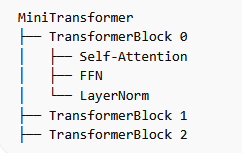



# Mini-GPT from Scratch (vollständig)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [7]:
class GPTBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            batch_first=True
        )

        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, attn_mask):
        attn_out, _ = self.attn(x, x, x, attn_mask=attn_mask)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x
        

In [8]:
# Schritt 2: Mini-GPT Modell
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, n_layers, max_len):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_len, embed_dim)

        self.blocks = nn.ModuleList([
            GPTBlock(embed_dim, num_heads, ff_dim)
            for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, idx):
        B, T = idx.shape

        pos = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)

        # Causal mask
        mask = torch.triu(
            torch.ones(T, T, device=idx.device),
            diagonal=1
        ).bool()

        for block in self.blocks:
            x = block(x, mask)

        x = self.ln_f(x)
        logits = self.head(x)
        return logits
        

In [9]:
# Schritt 3: Testlauf (Forward)
torch.manual_seed(0)

vocab_size = 20
model = MiniGPT(
    vocab_size=vocab_size,
    embed_dim=32,
    num_heads=4,
    ff_dim=64,
    n_layers=2,
    max_len=16
)

idx = torch.randint(0, vocab_size, (2, 10))
logits = model(idx)

print("Input shape :", idx.shape)
print("Logits shape:", logits.shape)

Input shape : torch.Size([2, 10])
Logits shape: torch.Size([2, 10, 20])
